In [1]:
import pandas as pd
import os
from utils.ml_utils_v2 import EmissionsPredictionPipeline, MultiOutputEmissionsPipeline
from utils.eda_utils import EDAUtils, DataCleaningUtils
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import joblib

/home/tony-ubuntu/anaconda3/envs/metamodel_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
SCRIPT_DIR_PATH = os.getcwd()
ROOT_DIR_PATH = os.path.dirname(SCRIPT_DIR_PATH)
DATA_DIR_PATH = os.path.join(ROOT_DIR_PATH, "data")
MAPPING_DIR_PATH = os.path.join(DATA_DIR_PATH, "mapping")
SSP_DIR_PATH = os.path.join(DATA_DIR_PATH, "ssp")
SIMULATION_DIR_PATH = os.path.join(SSP_DIR_PATH, "sisepuede_run_2025-01-14T17;04;06.975301_output_database")
TRAINING_DIR_PATH = os.path.join(DATA_DIR_PATH, "training")

In [4]:
TRAINING_DATA_PATH = os.path.join(TRAINING_DIR_PATH, "training_data_v4.1.csv")
training_df = pd.read_csv(TRAINING_DATA_PATH)
training_df = training_df.drop(columns=["primary_id", "future_id"])
training_df.head()

,group_1_ef_lvst_entferm,group_2_yf_agrc,group_3_demscalar_soil,group_4_demscalar_ippu,group_5_efficfactor_enfu_industrial_energy_fuel,group_6_elecfuelefficiency_trns,group_7_factor_waso_waste_per_capita_scalar_food,group_8_frac_fgtv,group_9_frac_agrc_agriculture_production_lost,group_10_frac_agrc,...,group_41_pij_lndu_other_to,group_42_pij_lndu_settlements_to,group_43_pij_lndu_wetlands_to,group_44_ef_agrc_anaerobicdom_rice_kg_ch4_ha,group_45_scalar_lvst_carrying_capacity,group_46_scalar_scoe_appliance_energy_demand,group_47_scalar_scoe_heat_energy_demand,emission_avg_last_five_years,emission_total,technical_cost
0,0.952436,0.360397,0.202990,0.995748,0.369859,0.919920,0.478450,0.445798,0.490988,0.510280,...,0.996557,0.053597,0.175103,0.379422,0.438093,0.149362,0.869757,52.248688,3318.009812,-5.143090
1,0.304955,0.204875,0.540658,0.800192,0.206396,0.777352,0.805727,0.536048,0.779857,0.623335,...,0.385371,0.246165,0.101025,0.717013,0.368791,0.774941,0.483352,49.914523,3219.904574,-6.899667
2,0.609262,0.366443,0.601808,0.916668,0.386475,0.181162,0.138910,0.768925,0.884425,0.232722,...,0.601590,0.122444,0.653845,0.216259,0.714853,0.881270,0.581230,-5.154870,2328.191406,-7.129115
3,0.815313,0.487444,0.323954,0.634299,0.064625,0.926815,0.633805,0.439346,0.027114,0.532020,...,0.938985,0.592915,0.564895,0.027725,0.138890,0.820709,0.250616,45.879563,3225.387997,-5.769771
4,0.973878,0.842718,0.884382,0.483039,0.455502,0.003343,0.571994,0.108021,0.346714,0.892123,...,0.492564,0.432240,0.662820,0.179231,0.631375,0.395960,0.661637,24.993688,2740.854420,-8.530492


## EDA

In [5]:
edau = EDAUtils()

In [6]:
target_cols = [col for col in training_df.columns if "emission" in col] + ["technical_cost"]
target_cols

['emission_avg_last_five_years', 'emission_total', 'technical_cost']

In [7]:
lhs_group_cols = [col for col in training_df.columns if col.startswith("group_")]
# lhs_group_cols

In [8]:
training_df[target_cols].describe()

,emission_avg_last_five_years,emission_total,technical_cost
count,9.840000e+02,9.840000e+02,9.840000e+02
mean,2.097051e+05,7.462781e+06,1.491879e+05
std,2.904940e+06,9.656415e+07,1.931283e+06
min,-8.721902e+00,2.234746e+03,-1.164369e+01
25%,3.063351e+01,2.880913e+03,-7.241585e+00
50%,4.309360e+01,3.101140e+03,-5.770438e+00
75%,5.654174e+01,3.321034e+03,-4.387264e+00
max,6.075109e+07,1.819204e+09,3.638401e+07


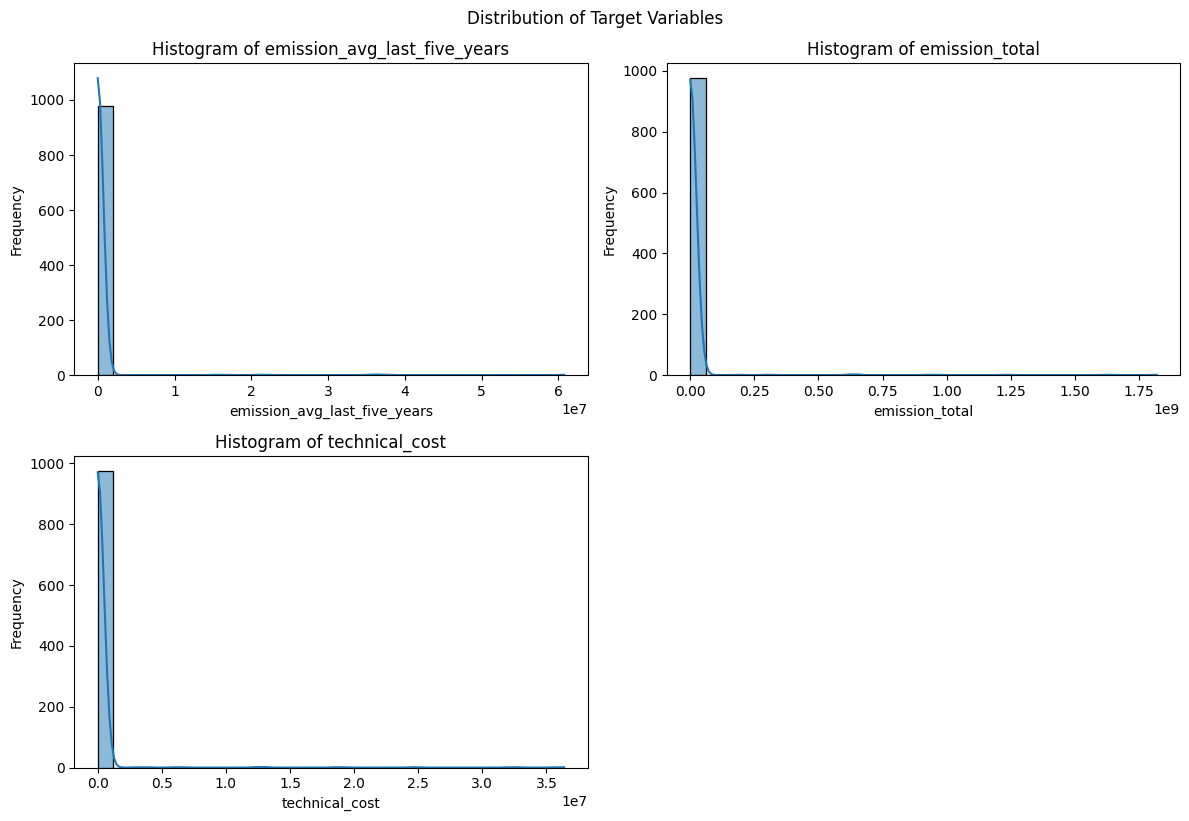

In [9]:
edau.plot_multiple_histograms(training_df, target_cols, title="Distribution of Target Variables")


In [20]:
edau.get_target_var_corr(training_df, "emission_total")
edau.get_target_var_corr(training_df, "emission_avg_last_five_years")
edau.get_target_var_corr(training_df, "technical_cost")


Correlation with target variable 'emission_total' (threshold: 0.1):
--------------------------------------------------
emission_total                 : 1.0000
technical_cost                 : 1.0000
emission_avg_last_five_years   : 0.5951


Correlation with target variable 'emission_avg_last_five_years' (threshold: 0.1):
--------------------------------------------------
emission_avg_last_five_years   : 1.0000
emission_total                 : 0.5951
technical_cost                 : 0.5951


Correlation with target variable 'technical_cost' (threshold: 0.1):
--------------------------------------------------
technical_cost                 : 1.0000
emission_total                 : 1.0000
emission_avg_last_five_years   : 0.5951




Correlation with target variable 'technical_cost' (threshold: 0.1):
--------------------------------------------------
technical_cost                 : 1.0000
emission_total                 : 1.0000
emission_avg_last_five_years   : 0.5951



In [12]:
# Find constant / near-constant cols
const_cols = edau.find_constant_columns(training_df)
near_const_cols = edau.find_near_constant_columns(training_df, threshold=1e-2)
print("Constant:", const_cols)
print("Near-constant:", near_const_cols)

Constant: []
Near-constant: []


In [13]:
# Outlier inspection
outliers = edau.find_outlier_columns(training_df, z_thresh=3.0)
print("Outlier percentages:", outliers)

Outlier percentages: {'emission_avg_last_five_years': 0.6097560975609756, 'emission_total': 0.7113821138211381, 'technical_cost': 0.7113821138211381}


## Data Cleaning

In [14]:
dcu = DataCleaningUtils()

In [15]:
training_df.shape

(984, 49)

In [16]:
training_df_cleaned = dcu.remove_outliers(training_df)
print("Shape after removing outliers:", training_df_cleaned.shape)

Shape after removing outliers: (976, 49)


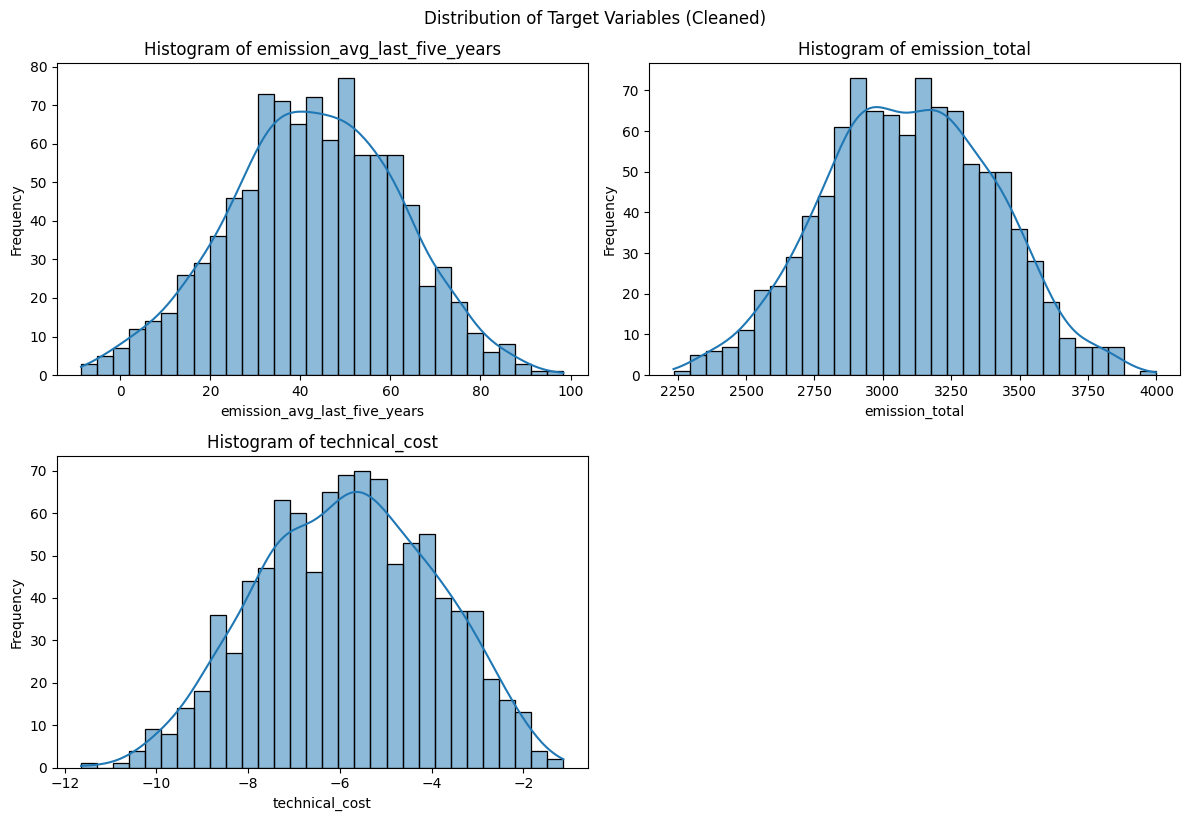

In [17]:
edau.plot_multiple_histograms(training_df_cleaned, target_cols, title="Distribution of Target Variables (Cleaned)")

In [18]:
outliers = edau.find_outlier_columns(training_df_cleaned, z_thresh=3.0)
print("Outlier percentages:", outliers)

Outlier percentages: {'technical_cost': 0.10245901639344263}


In [21]:
edau.get_target_var_corr(training_df_cleaned, "emission_total")
edau.get_target_var_corr(training_df_cleaned, "emission_avg_last_five_years")
edau.get_target_var_corr(training_df_cleaned, "technical_cost")


Correlation with target variable 'emission_total' (threshold: 0.1):
--------------------------------------------------
emission_total                 : 1.0000
emission_avg_last_five_years   : 0.9799
group_34_nemomod_en            : 0.7299
group_26_frac_inen_energy      : 0.3845
group_17_frac_trns_fuelmix     : 0.3037
group_5_efficfactor_enfu_industrial_energy_fuel : 0.1961
group_4_demscalar_ippu         : 0.1491
group_47_scalar_scoe_heat_energy_demand : 0.1029


Correlation with target variable 'emission_avg_last_five_years' (threshold: 0.1):
--------------------------------------------------
emission_avg_last_five_years   : 1.0000
emission_total                 : 0.9799
group_34_nemomod_en            : 0.6250
group_26_frac_inen_energy      : 0.3987
group_17_frac_trns_fuelmix     : 0.3932
group_4_demscalar_ippu         : 0.2247
group_5_efficfactor_enfu_industrial_energy_fuel : 0.1364
group_19_frac_trns_pkm_dem     : 0.1131
group_47_scalar_scoe_heat_energy_demand : 0.1082


Correlation

In [22]:
training_df_cleaned[target_cols].describe()

,emission_avg_last_five_years,emission_total,technical_cost
count,976.000000,976.000000,976.000000
mean,42.932567,3095.801327,-5.837645
std,18.803848,308.030848,1.904446
min,-8.721902,2234.745766,-11.643686
25%,30.633515,2877.949842,-7.258227
50%,42.967053,3096.227974,-5.787025
75%,56.439589,3316.055484,-4.415530
max,98.409631,3997.860060,-1.130138


In [23]:
# sns.pairplot(training_df_cleaned[[c for c in training_df_cleaned.columns if c.startswith("group_38") or c.startswith("group_39")] + ["total_negative_emissions"]])

In [24]:
# edau.plot_correlation_matrix(training_df_cleaned[[c for c in training_df_cleaned.columns if c.startswith("group_38") or c.startswith("group_39")] + ["total_negative_emissions"]])

## ML

### Individual Training

In [25]:
# negative_emissions_df = training_df_cleaned[lhs_group_cols + ["total_negative_emissions"]]
# positive_emissions_df = training_df_cleaned[lhs_group_cols + ["total_positive_emissions"]]


In [26]:
# negative_epp = EmissionsPredictionPipeline(
#     df=negative_emissions_df,
#     target="total_negative_emissions",
#     test_size=0.2,
#     random_state=42,
# )

# negative_epp.run(tune=False, log_transform=False, create_plots=False)

In [27]:
# positive_epp = EmissionsPredictionPipeline(
#     df=positive_emissions_df,
#     target="total_positive_emissions",
#     test_size=0.2,
#     random_state=42,
# )
# positive_epp.run(tune=False, log_transform=False, create_plots=False)

### Multi Output Training

Fitting 5 folds for each of 30 candidates, totalling 150 fits


Best XGB hyperparameters: {'subsample': 0.7, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.5}

=== XGB ===
emission_total                
  Train → MAE: 23.5670, RMSE: 29.4167, R²: 0.9906, SMAPE: 0.8%
   Test → MAE: 93.7886, RMSE: 114.2147, R²: 0.8756, SMAPE: 3.1%
emission_avg_last_five_years  
  Train → MAE: 1.7549, RMSE: 2.1639, R²: 0.9864, SMAPE: 6.9%
   Test → MAE: 6.9358, RMSE: 8.4984, R²: 0.8157, SMAPE: 23.0%
technical_cost                
  Train → MAE: 0.0826, RMSE: 0.1044, R²: 0.9970, SMAPE: 1.6%
   Test → MAE: 0.2118, RMSE: 0.2727, R²: 0.9792, SMAPE: 4.1%

=== MeanBaseline ===
emission_total                
  Train → MAE: 247.3779, RMSE: 303.6630, R²: 0.0000, SMAPE: 8.0%
   Test → MAE: 268.2725, RMSE: 324.1359, R²: -0.0015, SMAPE: 8.7%
emission_avg_last_five_years  
  Train → MAE: 14.8974, RMSE: 18.5309, R²: 0.0000, SMAPE: 38.7%
   Test → MAE: 16.3522, RMSE: 19.8106, R²: -0.0016, SMAPE: 41.1%
technical_c

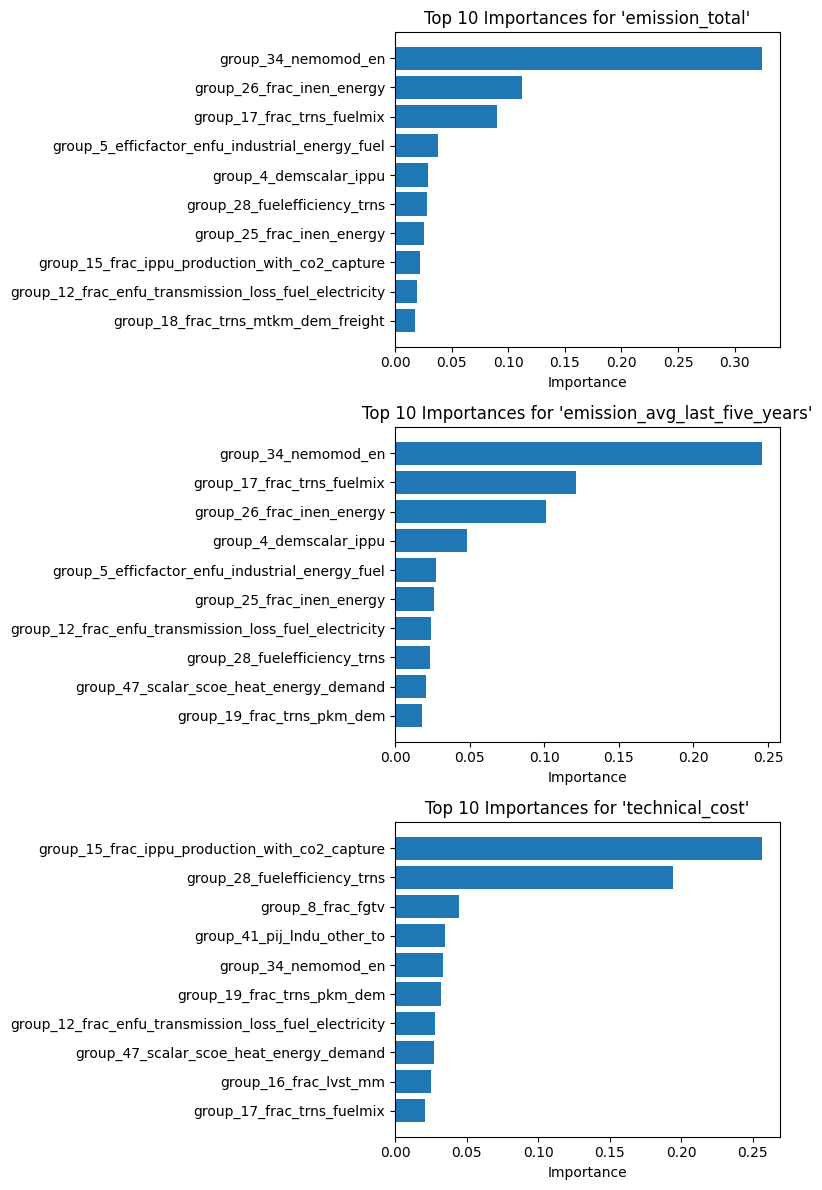

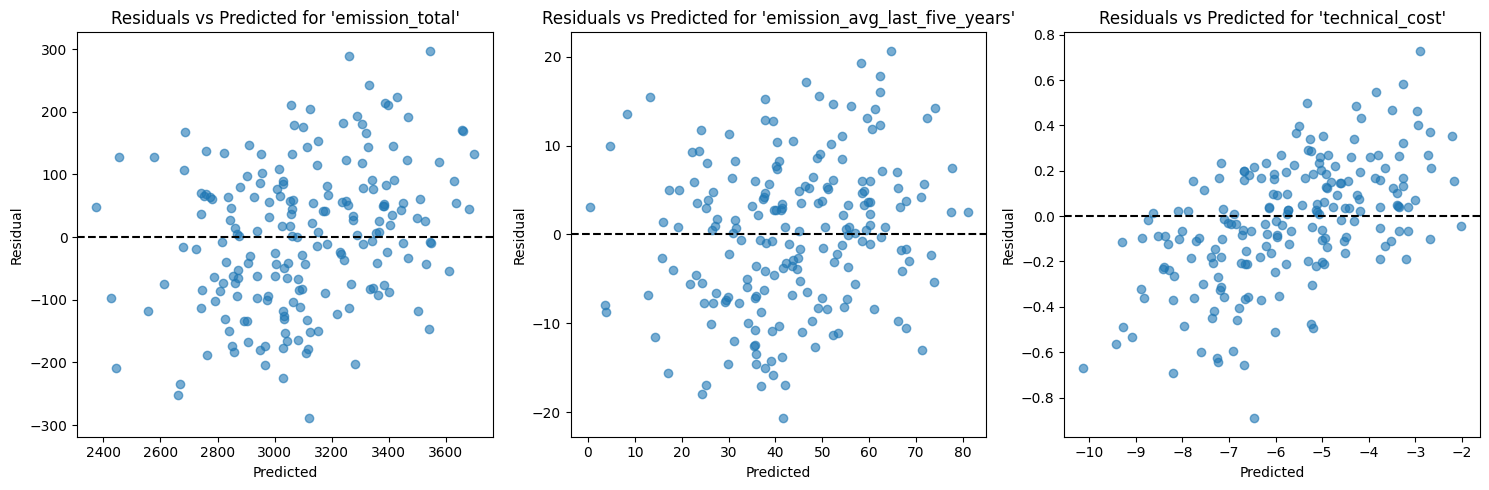

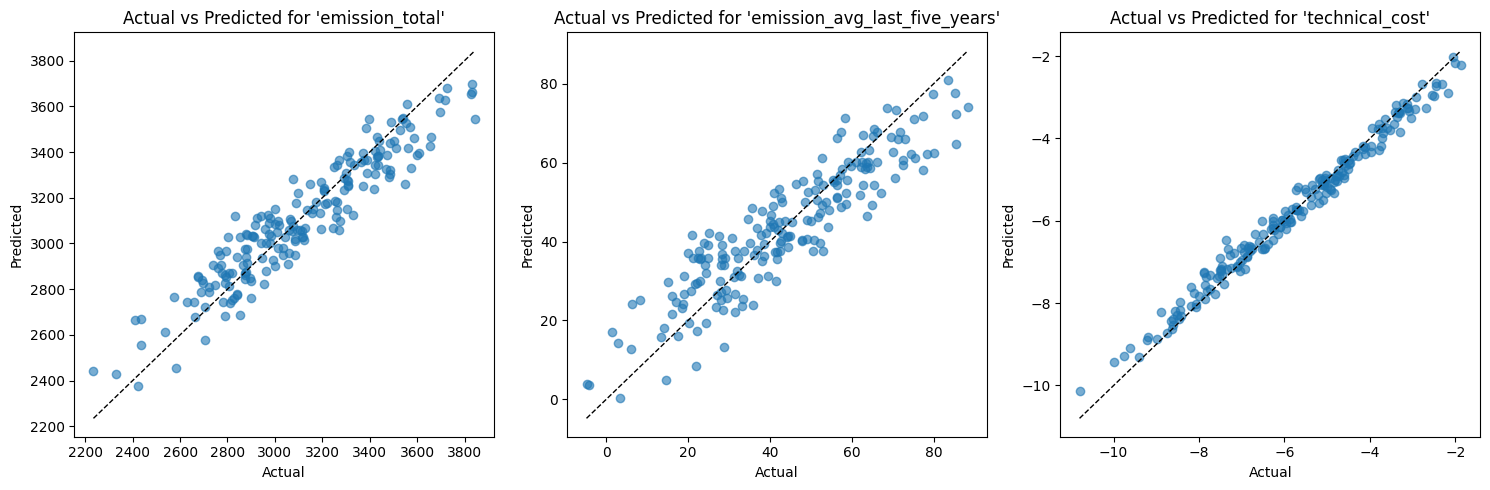

In [28]:
mulp = MultiOutputEmissionsPipeline(df=training_df_cleaned, targets=["emission_total", "emission_avg_last_five_years", "technical_cost"])
mulp.run(tune=True, log_transform=False, plot_figures=True)

## Save the trained and tuned model and use it to predict new data

In [29]:
training_df_cleaned.head()

,group_1_ef_lvst_entferm,group_2_yf_agrc,group_3_demscalar_soil,group_4_demscalar_ippu,group_5_efficfactor_enfu_industrial_energy_fuel,group_6_elecfuelefficiency_trns,group_7_factor_waso_waste_per_capita_scalar_food,group_8_frac_fgtv,group_9_frac_agrc_agriculture_production_lost,group_10_frac_agrc,...,group_41_pij_lndu_other_to,group_42_pij_lndu_settlements_to,group_43_pij_lndu_wetlands_to,group_44_ef_agrc_anaerobicdom_rice_kg_ch4_ha,group_45_scalar_lvst_carrying_capacity,group_46_scalar_scoe_appliance_energy_demand,group_47_scalar_scoe_heat_energy_demand,emission_avg_last_five_years,emission_total,technical_cost
0,0.952436,0.360397,0.202990,0.995748,0.369859,0.919920,0.478450,0.445798,0.490988,0.510280,...,0.996557,0.053597,0.175103,0.379422,0.438093,0.149362,0.869757,52.248688,3318.009812,-5.143090
1,0.304955,0.204875,0.540658,0.800192,0.206396,0.777352,0.805727,0.536048,0.779857,0.623335,...,0.385371,0.246165,0.101025,0.717013,0.368791,0.774941,0.483352,49.914523,3219.904574,-6.899667
2,0.609262,0.366443,0.601808,0.916668,0.386475,0.181162,0.138910,0.768925,0.884425,0.232722,...,0.601590,0.122444,0.653845,0.216259,0.714853,0.881270,0.581230,-5.154870,2328.191406,-7.129115
3,0.815313,0.487444,0.323954,0.634299,0.064625,0.926815,0.633805,0.439346,0.027114,0.532020,...,0.938985,0.592915,0.564895,0.027725,0.138890,0.820709,0.250616,45.879563,3225.387997,-5.769771
4,0.973878,0.842718,0.884382,0.483039,0.455502,0.003343,0.571994,0.108021,0.346714,0.892123,...,0.492564,0.432240,0.662820,0.179231,0.631375,0.395960,0.661637,24.993688,2740.854420,-8.530492


In [30]:
# Get a single row from training_df_cleaned for prediction
single_row = training_df_cleaned.iloc[0].drop(["emission_total", "emission_avg_last_five_years", "technical_cost"])
single_row = single_row.to_frame().T  # Convert to DataFrame
single_row

,group_1_ef_lvst_entferm,group_2_yf_agrc,group_3_demscalar_soil,group_4_demscalar_ippu,group_5_efficfactor_enfu_industrial_energy_fuel,group_6_elecfuelefficiency_trns,group_7_factor_waso_waste_per_capita_scalar_food,group_8_frac_fgtv,group_9_frac_agrc_agriculture_production_lost,group_10_frac_agrc,...,group_38_pij_lndu_forests_primary_to,group_39_pij_lndu_forests_secondary_to,group_40_pij_lndu_grasslands+,group_41_pij_lndu_other_to,group_42_pij_lndu_settlements_to,group_43_pij_lndu_wetlands_to,group_44_ef_agrc_anaerobicdom_rice_kg_ch4_ha,group_45_scalar_lvst_carrying_capacity,group_46_scalar_scoe_appliance_energy_demand,group_47_scalar_scoe_heat_energy_demand
0,0.952436,0.360397,0.20299,0.995748,0.369859,0.91992,0.47845,0.445798,0.490988,0.51028,...,0.941385,0.873715,0.289038,0.996557,0.053597,0.175103,0.379422,0.438093,0.149362,0.869757


In [31]:
# Predict using the trained model
predictions = mulp.predict(single_row)
print("Predictions for single row:")
print(predictions)

Predictions for single row:
   emission_total  emission_avg_last_five_years  technical_cost
0     3325.735352                     52.600079       -5.108672


In [32]:
# Save the trained model
xgb_pipeline = mulp.pipelines["XGB"]
TRAINED_MODELS_DIR = os.path.join(SCRIPT_DIR_PATH, "trained_models")
model_file_name = "xgb_pipeline_5.1.pkl"
os.makedirs(TRAINED_MODELS_DIR, exist_ok=True)

MODEL_PATH = os.path.join(TRAINED_MODELS_DIR, model_file_name)
if os.path.exists(MODEL_PATH):
    print(f"Model {model_file_name} already exists at {MODEL_PATH}. Make sure you don't overwrite an existing model.")
else:
    print(f"Saving model {model_file_name} to {MODEL_PATH}.")
    joblib.dump(xgb_pipeline, MODEL_PATH)


Saving model xgb_pipeline_5.1.pkl to /home/tony-ubuntu/decision_sciences/ssp_louisiana/metamodel/notebooks/trained_models/xgb_pipeline_5.1.pkl.


In [33]:
# Load the trained model and test predictions
xgb_pipeline_loaded = joblib.load(MODEL_PATH)

In [34]:
# Predict using the trained model
predictions = mulp.predict(single_row, ml_pipeline=xgb_pipeline_loaded)
print("Predictions for single row:")
print(predictions)

Predictions for single row:
   emission_total  emission_avg_last_five_years  technical_cost
0     3325.735352                     52.600079       -5.108672
